# Session2 사전 과제
## CNN · RNN · LSTM · GRU · Seq2Seq

---
# 1. CNN (합성곱 신경망, Convolutional Neural Network)

CNN은 **이미지처럼 공간적 구조가 있는 데이터**를 처리하기 위해 만들어진 신경망이다.  
기존 FC(완전연결) 신경망은 이미지를 1D로 펴버려서 공간 정보를 날렸는데, CNN은 필터로 지역 패턴을 뽑아서 그걸 방지한다.

예를 들어 고양이 사진을 분류한다고 할 때:  
- FC: 픽셀 전부를 일렬로 펴서 입력 → 귀가 어디 있는지 같은 위치 정보 소실  
- CNN: 필터가 슬라이딩하면서 "귀 모양", "눈 모양" 등 **지역 특징을 직접 탐지**

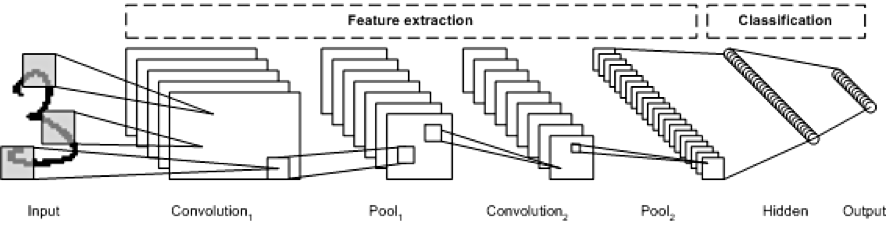

## 1.1 CNN 전체 구조

```
입력 이미지
  → [Conv → ReLU → Pooling] × N   ← 특징 추출 블록
  → Flatten
  → [FC Layer] × M                ← 분류 블록
  → Softmax → 출력 (클래스 확률)
```

**입력 표현**  
이미지는 `(H, W, C)` 텐서로 표현된다.  
예: 28×28 흑백 → `(28, 28, 1)` / 224×224 컬러 → `(224, 224, 3)`

**배치 처리**  
실제 학습 시에는 `(batch_size, H, W, C)` 4D 텐서가 흐른다.  
예: 32장 묶음이면 `(32, 224, 224, 3)`

## 1.2 핵심 레이어 상세

### 합성곱(Convolution) 레이어

필터(커널)가 입력을 슬라이딩하면서 내적을 수행해 Feature Map을 생성.

$$\text{Feature Map}(i,j) = \sum_{m}\sum_{n} W(m,n) \cdot X(i \cdot s+m,\ j \cdot s+n) + b$$

여기서 $s$는 스트라이드(stride).

**출력 크기 공식:**
$$O = \left\lfloor \frac{I - K + 2P}{S} \right\rfloor + 1$$

- $I$: 입력 크기, $K$: 필터 크기, $P$: 패딩, $S$: 스트라이드

> **예시**: 입력 32×32, 필터 3×3, 패딩 1, 스트라이드 1  
> → 출력 = (32 - 3 + 2×1) / 1 + 1 = **32×32** (크기 유지됨)

---

### 패딩(Padding)

- **Valid 패딩** (P=0): 패딩 없음 → 출력이 입력보다 작아짐
- **Same 패딩**: 출력 크기 = 입력 크기 유지 → 경계 픽셀 정보 보존

---

### 활성화 함수: ReLU

$$\text{ReLU}(x) = \max(0, x)$$

음수 → 0으로 날림. 이게 왜 중요하냐면:  
- Sigmoid/tanh는 값이 크거나 작으면 gradient가 거의 0 → **기울기 소실** 발생  
- ReLU는 양수 구간에서 gradient가 항상 1 → 빠른 학습

---

### 풀링(Pooling) 레이어

특징 맵을 공간적으로 줄이는 다운샘플링 연산.

```
Max Pooling (2×2, stride 2) 예시:

입력:          출력:
1  3  2  4     3  4
5  6  1  2  →  6  3
1  2  3  1
4  1  0  3
```

**역할**:
- 파라미터 수 감소 → 과적합 방지
- 위치 불변성(Translation Invariance) 확보: 고양이가 사진 왼쪽이든 오른쪽이든 탐지 가능

---

### Flatten + FC Layer

Flatten: 3D Feature Map을 1D 벡터로 펌  
예: `(7, 7, 512)` → `(25088,)`  

FC Layer: 일반적인 뉴럴넷으로 최종 분류 수행

---

### Batch Normalization (자주 사용)

각 배치의 활성값을 정규화해서 학습을 안정화.

$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$

- Conv → BN → ReLU 순으로 붙이는 게 일반적
- 학습률을 크게 써도 안정적 / Dropout 없이도 규제 효과 있음

---

### Dropout (과적합 방지)

훈련 시 뉴런을 확률 $p$로 랜덤하게 꺼버림. 테스트 시엔 전부 켬.  
FC Layer에 주로 적용 (예: p=0.5).

## 1.3 대표 CNN 모델

| 모델 | 연도 | 레이어 | 핵심 아이디어 |
|------|------|--------|---------------|
| **LeNet-5** | 1998 | 7 | 최초의 실용적 CNN. MNIST 손글씨 인식 |
| **AlexNet** | 2012 | 8 | ImageNet 우승. ReLU, Dropout, GPU 학습 도입 |
| **VGGNet** | 2014 | 16/19 | 3×3 필터 반복. 단순하고 깊게 |
| **GoogLeNet** | 2014 | 22 | Inception 모듈: 다양한 크기 필터 병렬 적용 |
| **ResNet** | 2015 | 50/101/152 | **Skip Connection**으로 기울기 소실 해결 |
| **DenseNet** | 2017 | - | 모든 레이어를 연결(Dense Connection) |
| **EfficientNet** | 2019 | - | 깊이·너비·해상도를 균형 있게 스케일링 |

---

### ResNet - Skip Connection (핵심!)
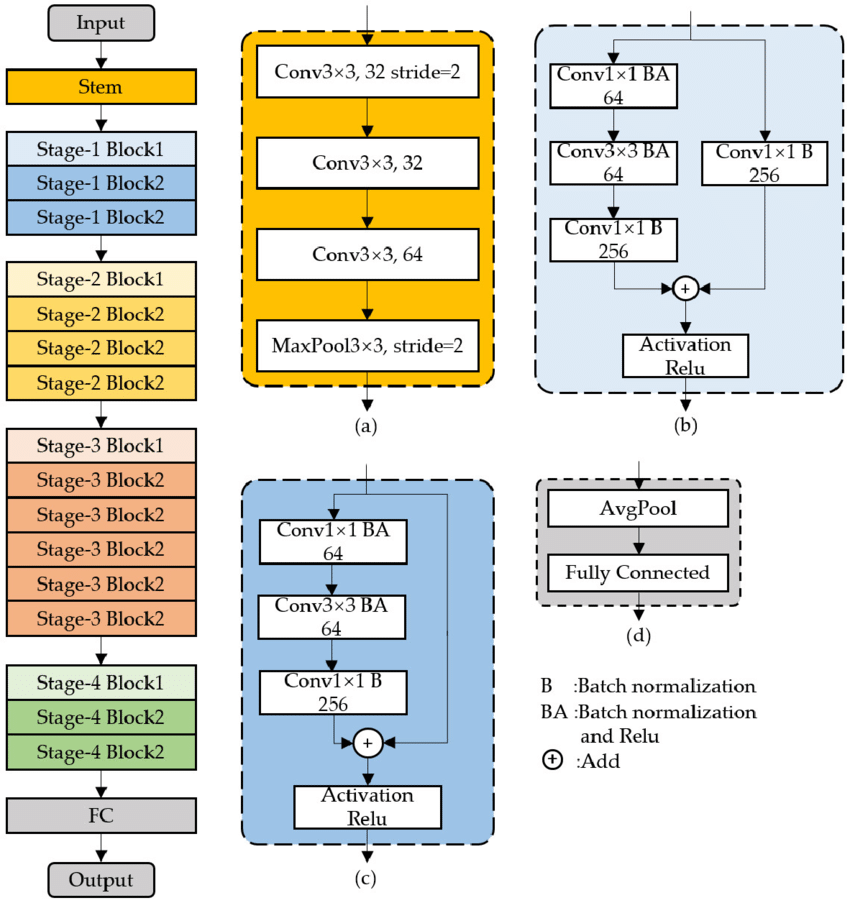

$$H(x) = F(x) + x$$

레이어가 $F(x)$를 직접 학습하는 게 아니라 **잔차(residual) $F(x) = H(x) - x$** 를 학습하게 만들었음.

```
일반 신경망:   x → [Conv→BN→ReLU→Conv→BN] → H(x)

ResNet:        x → [Conv→BN→ReLU→Conv→BN] → F(x)
               x ─────────────────────────↗ (+)
               최종 출력: H(x) = F(x) + x
```

**왜 좋냐**: 최악의 경우 $F(x) = 0$ 학습하면 항등함수(identity mapping)가 되므로, 레이어를 아무리 깊게 쌓아도 성능이 무너지지 않음.  
→ 152층짜리 네트워크도 안정적으로 학습 가능!

---

### GoogLeNet Inception Module

```
         입력
    ┌────┼────┬────────┐
  1×1  1×1  1×1     MaxPool
  Conv  Conv  Conv     3×3
        │     │         │
       3×3   5×5      1×1
       Conv  Conv      Conv
    └────┴────┴────────┘
           Concat
```

여러 크기의 필터를 동시에 적용 → 다양한 스케일의 특징을 한번에 캡처  
1×1 Conv는 채널 수 줄여서 연산량 절감 (Bottleneck 역할)

## 1.4 이미지 딥러닝 응용

### 분류 (Image Classification)
- 입력 이미지 → 클래스 1개 출력
- 예: ResNet으로 개/고양이 분류, ImageNet 1000개 클래스 분류

### 객체 감지 (Object Detection)
- 이미지 내 여러 객체의 **위치(Bounding Box) + 클래스** 동시 예측
- **R-CNN 계열**: Region Proposal → CNN 특징 추출 → 분류 (느리지만 정확)
- **YOLO**: 이미지를 그리드로 나눠 한 번에 예측 (실시간 가능)

```
YOLO 아이디어:
이미지를 S×S 그리드로 분할
각 셀이 B개의 BBox 예측 (x, y, w, h, confidence)
+ C개의 클래스 확률
→ 전부 하나의 신경망으로 한 번에 예측!
```

### 이미지 분할 (Segmentation)
- **Semantic Segmentation**: 픽셀마다 클래스 라벨 예측 (FCN, DeepLab)
- **Instance Segmentation**: 같은 클래스 다른 개체도 구분 (Mask R-CNN)

### 이미지 생성
- **GAN (적대적 생성 신경망)**: Generator vs Discriminator 대립 구조로 진짜 같은 이미지 생성
- **VAE**: 잠재 공간(Latent Space)에서 샘플링 → 이미지 생성
- **Diffusion Model**: 최근 Stable Diffusion, DALL·E 등이 이 방식 (노이즈 제거 반복)

### 기타 응용
- **의료 영상**: X-ray·MRI에서 종양 탐지 (의사 보조 진단)
- **자율주행**: 도로·보행자·신호등 실시간 인식
- **얼굴 인식**: FaceNet — 얼굴을 128차원 임베딩으로 표현 → 거리 계산으로 동일인 판별
- **문서 인식**: OCR, 영수증 자동 처리

---
# 2. RNN (순환 신경망, Recurrent Neural Network)

CNN이 공간 데이터를 다룬다면, RNN은 **시간 순서가 있는 데이터**를 다룬다.

예를 들어:
- "나는 밥을 ___" → 다음 단어를 예측하려면 앞 문맥이 필요함
- 주가 예측: 오늘 가격은 어제, 그저께 가격과 연관됨
- 음성 인식: 현재 음소는 이전 음소와 연속됨

FC 신경망은 입력을 독립적으로 봐서 이런 **시퀀스 의존성**을 못 잡음.

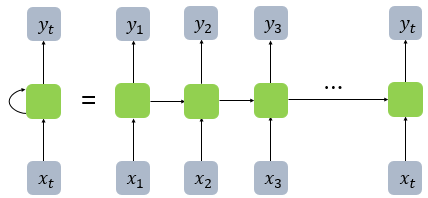

## 2.1 RNN 구조와 원리

### 핵심 아이디어: 은닉 상태(Hidden State)를 다음 시점으로 전달

```
시점:   t=1         t=2         t=3
        ↓           ↓           ↓
x_1 → [RNN] → h_1 → [RNN] → h_2 → [RNN] → h_3
        ↓               ↓               ↓
       y_1             y_2             y_3
```

은닉 상태 $h_t$가 이전 시점의 "기억"을 들고 다님.

### 수식

$$h_t = \tanh(W_h \cdot h_{t-1} + W_x \cdot x_t + b_h)$$
$$y_t = W_y \cdot h_t + b_y$$

- $x_t$: 현재 입력
- $h_{t-1}$: 이전 은닉 상태 ("과거 기억")
- $W_h, W_x$: 가중치 행렬 (시점에 상관없이 **공유됨** — Parameter Sharing)
- $\tanh$: -1~1 범위로 압축

>가중치가 모든 시점에서 공유되므로 파라미터 수가 적음. 하지만 이게 나중에 기울기 소실 문제의 원인이 되기도 함.

### 처리 방식 유형

```
One-to-One:    x → y                  (일반 신경망)
One-to-Many:   x → y1, y2, y3 ...    (이미지 → 캡션 생성)
Many-to-One:   x1, x2, x3 → y        (감성 분석, 스팸 분류)
Many-to-Many:  x1...xn → y1...ym     (기계 번역, 음성 인식)
```

### 역전파: BPTT (Backpropagation Through Time)

RNN의 역전파는 시간을 거슬러 올라가면서 gradient를 계산함.  
시퀀스 길이가 $T$면 $T$번 연속으로 가중치 곱해지면서 gradient가 흐름.  
→ 이게 기울기 소실/폭발의 원인!

## 2.2 RNN의 한계

### 한계 1: 기울기 소실 / 폭발 (Vanishing / Exploding Gradient)

BPTT로 gradient를 계산할 때 $\frac{\partial h_t}{\partial h_1}$를 구하면:

$$\frac{\partial h_t}{\partial h_1} = \prod_{k=2}^{t} \frac{\partial h_k}{\partial h_{k-1}} = \prod_{k=2}^{t} W_h^T \cdot \text{diag}(\tanh'(\cdot))$$

- $|W_h| < 1$이 반복되면 → gradient가 지수적으로 0에 수렴 (**소실**)
- $|W_h| > 1$이 반복되면 → gradient가 지수적으로 폭발 (**폭발** → NaN 발생)

**결과**: 문장이 길어질수록 앞쪽 단어의 영향이 사라짐  
예: "나는 어제 서울에서 맛있는 밥을 ___" 에서 '나는'이라는 주어 정보가 소실됨

**완화법**:
- 기울기 폭발: Gradient Clipping (임계값 초과 시 스케일 다운)
- 기울기 소실: LSTM / GRU 사용 (근본적 해결)

```python
# Gradient Clipping 예시 (PyTorch)
loss.backward()
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # 1.0 이상이면 클리핑
optimizer.step()
```

### 한계 2: 장기 의존성 (Long-term Dependency) 학습 불가

위 기울기 소실의 직접적 결과.  
"The cat that ate the fish **was** full" — was의 주어인 cat이 멀리 있으면 RNN이 연결을 못 잡음.

### 한계 3: 병렬 처리 불가

$h_t$를 계산하려면 반드시 $h_{t-1}$이 필요 → **순차 처리만 가능**  
→ GPU 병렬화 못 씀 → 학습 매우 느림  
→ 이게 Transformer가 RNN을 대체한 핵심 이유 중 하나

### 한계 4: 고정 크기 Context

은닉 상태 $h_t$는 고정 크기 벡터 → 시퀀스가 길수록 정보 압축에 한계

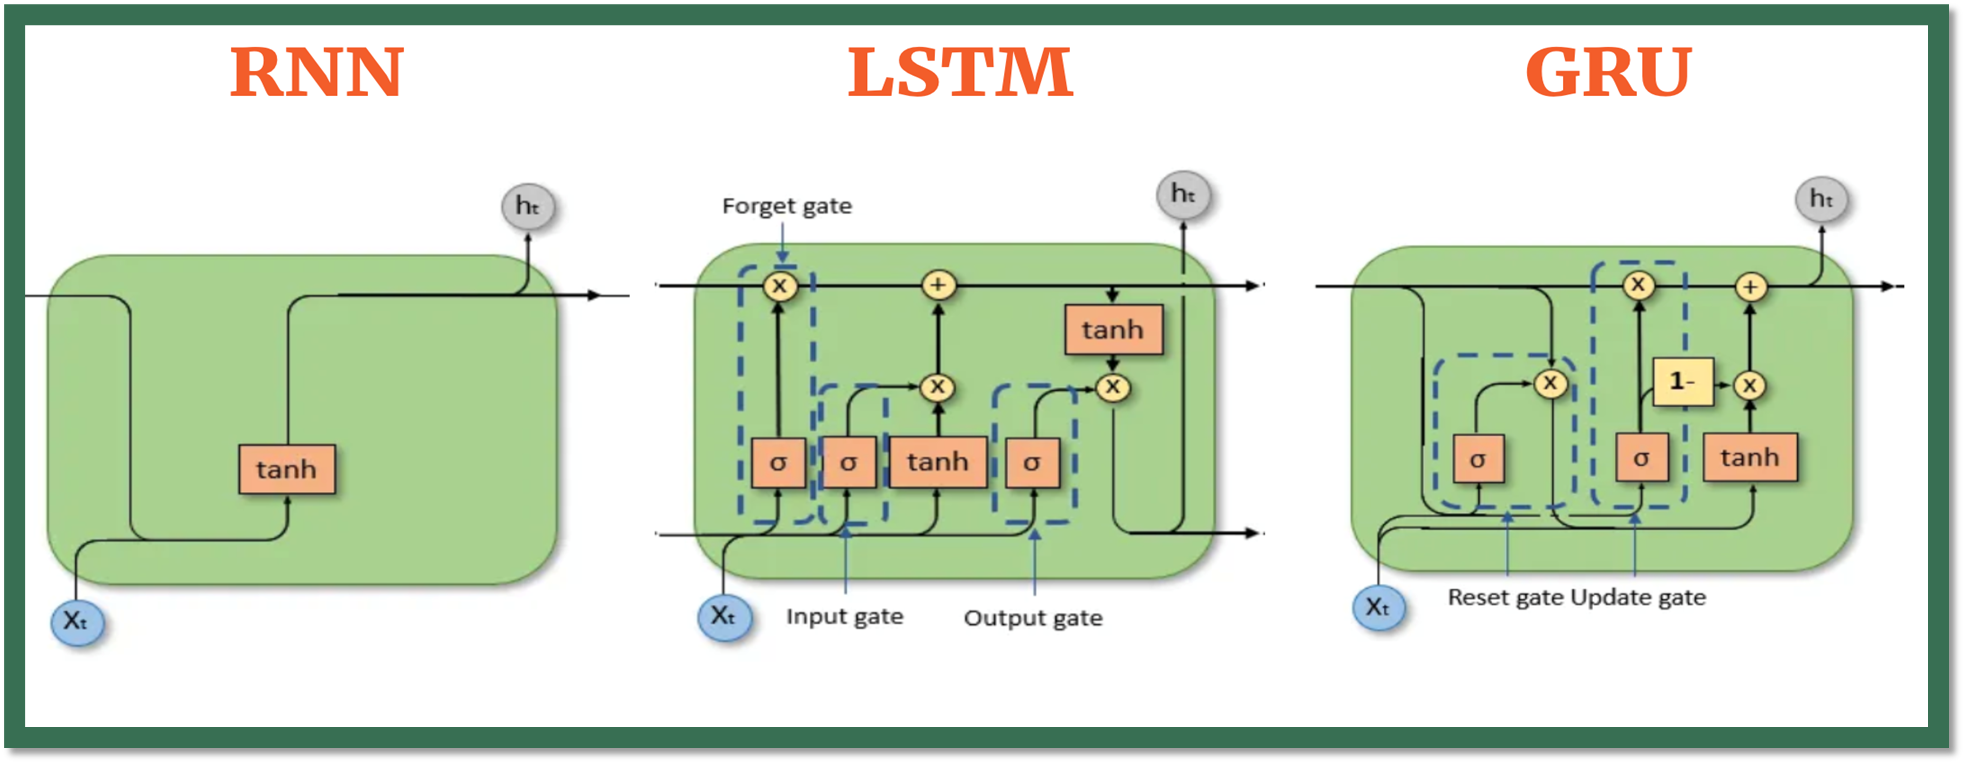

## 2.3 LSTM과 GRU

RNN의 기울기 소실 문제를 **게이트(Gate) 메커니즘**으로 해결.

---

### LSTM (Long Short-Term Memory)

1997년 Hochreiter & Schmidhuber 제안. **셀 상태(Cell State)**라는 별도의 메모리 통로를 추가.

```
핵심 구조:
    [Forget] → 과거 중 뭘 버릴지
    [Input]  → 새 정보 중 뭘 저장할지
    [Output] → 은닉 상태로 뭘 출력할지
```

**수식:**

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \quad \text{[Forget Gate]}$$
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \quad \text{[Input Gate]}$$
$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C) \quad \text{[후보 셀 상태]}$$
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t \quad \text{[셀 상태 업데이트]}$$
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \quad \text{[Output Gate]}$$
$$h_t = o_t \odot \tanh(C_t) \quad \text{[은닉 상태]}$$

- $\sigma$: Sigmoid (0~1 → 게이트 열고/닫기)
- $\odot$: 원소별 곱(Hadamard product)
- $C_t$: 셀 상태 — 기울기 소실 없이 흐르는 **고속도로** 역할

> **직관**: 셀 상태는 컨베이어 벨트처럼 정보를 멀리까지 전달. 게이트가 필요한 정보를 추가/제거하는 역할.

---

### GRU (Gated Recurrent Unit)

2014년 Cho et al. 제안. LSTM을 단순화한 버전.  
셀 상태를 없애고 **Reset Gate + Update Gate** 2개만 사용.

$$r_t = \sigma(W_r \cdot [h_{t-1}, x_t]) \quad \text{[Reset Gate: 과거 얼마나 무시?]}$$
$$z_t = \sigma(W_z \cdot [h_{t-1}, x_t]) \quad \text{[Update Gate: 새 정보 얼마나 반영?]}$$
$$\tilde{h}_t = \tanh(W \cdot [r_t \odot h_{t-1}, x_t]) \quad \text{[후보 은닉 상태]}$$
$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t \quad \text{[최종 업데이트]}$$

- Update Gate $z_t$가 1에 가까울수록 → 새 정보 많이 반영
- Update Gate $z_t$가 0에 가까울수록 → 과거 상태 유지

---

### LSTM vs GRU 비교

| 항목 | LSTM | GRU |
|------|------|-----|
| 게이트 수 | 3개 (Forget/Input/Output) | 2개 (Reset/Update) |
| 상태 | Cell State + Hidden State | Hidden State만 |
| 파라미터 | 많음 | 적음 (~75%) |
| 학습 속도 | 느림 | 빠름 |
| 성능 | 데이터 많을 때 유리 | 데이터 적을 때 유리 |
| 언제 쓸까 | 복잡한 장기 의존성 | 빠른 실험, 작은 데이터셋 |

---
# 3. Seq2Seq

RNN/LSTM의 Many-to-Many를 체계화한 구조.  
**입력 시퀀스 길이 ≠ 출력 시퀀스 길이**인 경우를 다루기 위해 등장.

기계 번역을 생각하면 직관적:  
- 한국어 "나는 밥을 먹었다" (5 토큰) → 영어 "I ate rice" (3 토큰)
- 길이가 달라서 단순 RNN Many-to-Many로는 처리 곤란

## 3.1 Seq2Seq 개념


### 언제 쓰나?

| 태스크 | 입력 | 출력 |
|--------|------|------|
| 기계 번역 | 한국어 문장 | 영어 문장 |
| 텍스트 요약 | 긴 기사 | 짧은 요약 |
| 챗봇 | 질문 | 대답 |
| 음성 인식 (ASR) | 음성 프레임 시퀀스 | 텍스트 |
| TTS | 텍스트 | 음성 스펙트로그램 |
| 이미지 캡셔닝 | 이미지 (CNN 피처) | 설명 문장 |
| SQL 생성 | 자연어 질문 | SQL 쿼리 |

### 핵심 아이디어

1. **Encoder**: 입력 시퀀스 전체를 읽고 의미를 하나의 벡터로 압축
2. **Context Vector**: 압축된 의미 벡터 (Encoder의 마지막 은닉 상태)
3. **Decoder**: Context Vector를 받아 출력 시퀀스를 하나씩 생성

### Teacher Forcing

훈련 시 Decoder 입력으로 **이전 예측 값**이 아니라 **실제 정답**을 넣어주는 기법.  
초기에 예측이 엉터리여도 안정적으로 학습 가능.

```
훈련 시:  Decoder 입력 = [<SOS>, 나는, 밥을, 먹었다]  (실제 정답)
추론 시:  Decoder 입력 = [<SOS>, 이전_예측_토큰, ...]  (자기 예측)
```

## 3.2 Encoder-Decoder 구조
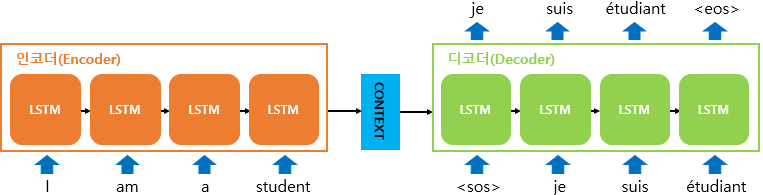

### 전체 흐름

```
[Encoder]
"I" → [LSTM] → h1
"ate" → [LSTM] → h2  (h1 전달받음)
"rice" → [LSTM] → h3  → Context Vector (h3 = 마지막 은닉 상태)

[Decoder]  (Context Vector로 초기화)
<SOS> → [LSTM] → "나는"
"나는" → [LSTM] → "밥을"
"밥을" → [LSTM] → "먹었다"
"먹었다" → [LSTM] → <EOS>  → 종료
```

### 보틀넥(Bottleneck) 문제

Context Vector가 **고정 크기** 벡터 → 긴 문장의 모든 정보를 다 담기 어려움  
예: 100단어 문서를 256차원 벡터 하나로 압축하면 정보 손실 발생

### Attention Mechanism으로 해결

Decoder가 각 출력을 생성할 때 Encoder의 **모든 은닉 상태**를 참조.  
각 Encoder 상태에 가중치(attention score)를 부여해서 동적으로 중요한 부분 강조.

$$\text{score}(h_t^{dec}, h_s^{enc}) = h_t^{dec} \cdot h_s^{enc} \quad \text{(Dot-product Attention)}$$
$$\alpha_{ts} = \text{softmax}(\text{score}(h_t^{dec}, h_s^{enc}))$$
$$c_t = \sum_s \alpha_{ts} \cdot h_s^{enc} \quad \text{(가중 합 = Context)}$$

```
예시: "밥을" 생성 시
"I" → attention 0.05
"ate" → attention 0.90   ← 동사를 번역하니 ate에 집중!
"rice" → attention 0.05
```

→ Attention이 Transformer의 핵심 메커니즘으로 발전

## 감사합니다! 🦭